> **Mitra AI Projects — Course Notebook**  
> This is a real-world applied notebook from the AIML-Engineering-Lab.  
> Read each cell, run the code, and modify it to experiment.  
> Your work saves automatically in your browser.

---


# Post 003 — Tree-Based Learning: EV Battery Thermal Runaway Prediction

**AI Engineering Lab Series**

## The Problem

Lithium-ion batteries can experience **thermal runaway** — a chain reaction where heat generates more heat, ultimately causing a fire. This is rare (~5% of batteries under stress), but catastrophic when it happens. The challenge is that the failure is caused by a *combination* of conditions, not a single threshold. A hot battery is fine if it is charging slowly with good cooling. The same temperature is dangerous if the battery is old, charging fast, and the cooling system is weak.

This is exactly the type of problem where **Decision Trees and Random Forests excel**: they learn multi-condition rules like `IF charge_rate > 15 AND ambient_temp > 38 AND cooling_flow < 2 THEN Fire`.

## Dataset

| Feature | Description | Units |
|---|---|---|
| `charge_rate_kw` | Power delivered during charging | kW |
| `ambient_temp_c` | Temperature of the environment | °C |
| `cooling_flow_rate` | Coolant flow through the battery pack | L/min |
| `cell_voltage_variance` | Spread in voltage across cells (imbalance indicator) | V |
| `age_cycles` | Number of charge/discharge cycles completed | cycles |
| `thermal_runaway` | **Target**: 1 = Fire, 0 = Safe | — |

**Class imbalance:** ~5% fire rate (real-world rare-event scenario)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {'safe': '#4CAF50', 'fire': '#F44336', 'tree': '#1565C0', 'rf': '#E65100'}

df = pd.read_csv('../data/ev_battery_thermal_runaway.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (8000, 6)


,charge_rate_kw,ambient_temp_c,cooling_flow_rate,cell_voltage_variance,age_cycles,thermal_runaway
0,7.020847,24.643636,6.387429,0.020089,147,0
1,6.869560,28.420442,3.661899,0.002354,666,0
2,6.846007,30.497642,2.977440,0.000844,696,0
3,4.962605,21.085149,5.126579,0.010778,924,0
4,6.272799,21.417126,4.924285,0.000766,962,0


## 1. Exploratory Data Analysis

Before building any model, we need to understand the data. The key question is: **what does a battery look like just before it catches fire?**

In [2]:
print('Class distribution:')
print(df['thermal_runaway'].value_counts(normalize=True).round(3))
print(f'\nFire rate: {df["thermal_runaway"].mean():.1%}')

print('\nStatistics by class:')
df.groupby('thermal_runaway').agg(['mean', 'std']).round(3)

Class distribution:
thermal_runaway
0    0.95
1    0.05
Name: proportion, dtype: float64

Fire rate: 5.0%

Statistics by class:


charge_rate_kw        ambient_temp_c        cooling_flow_rate  \
                          mean    std           mean    std              mean   
thermal_runaway                                                                 
0                        6.991  1.504         21.931  6.027             5.029   
1                       18.003  2.375         41.917  3.906             1.476   

                       cell_voltage_variance        age_cycles           
                   std                  mean    std       mean      std  
thermal_runaway                                                          
0                1.001                 0.005  0.005    492.017  287.659  
1                0.514                 0.045  0.034   1082.428  258.873

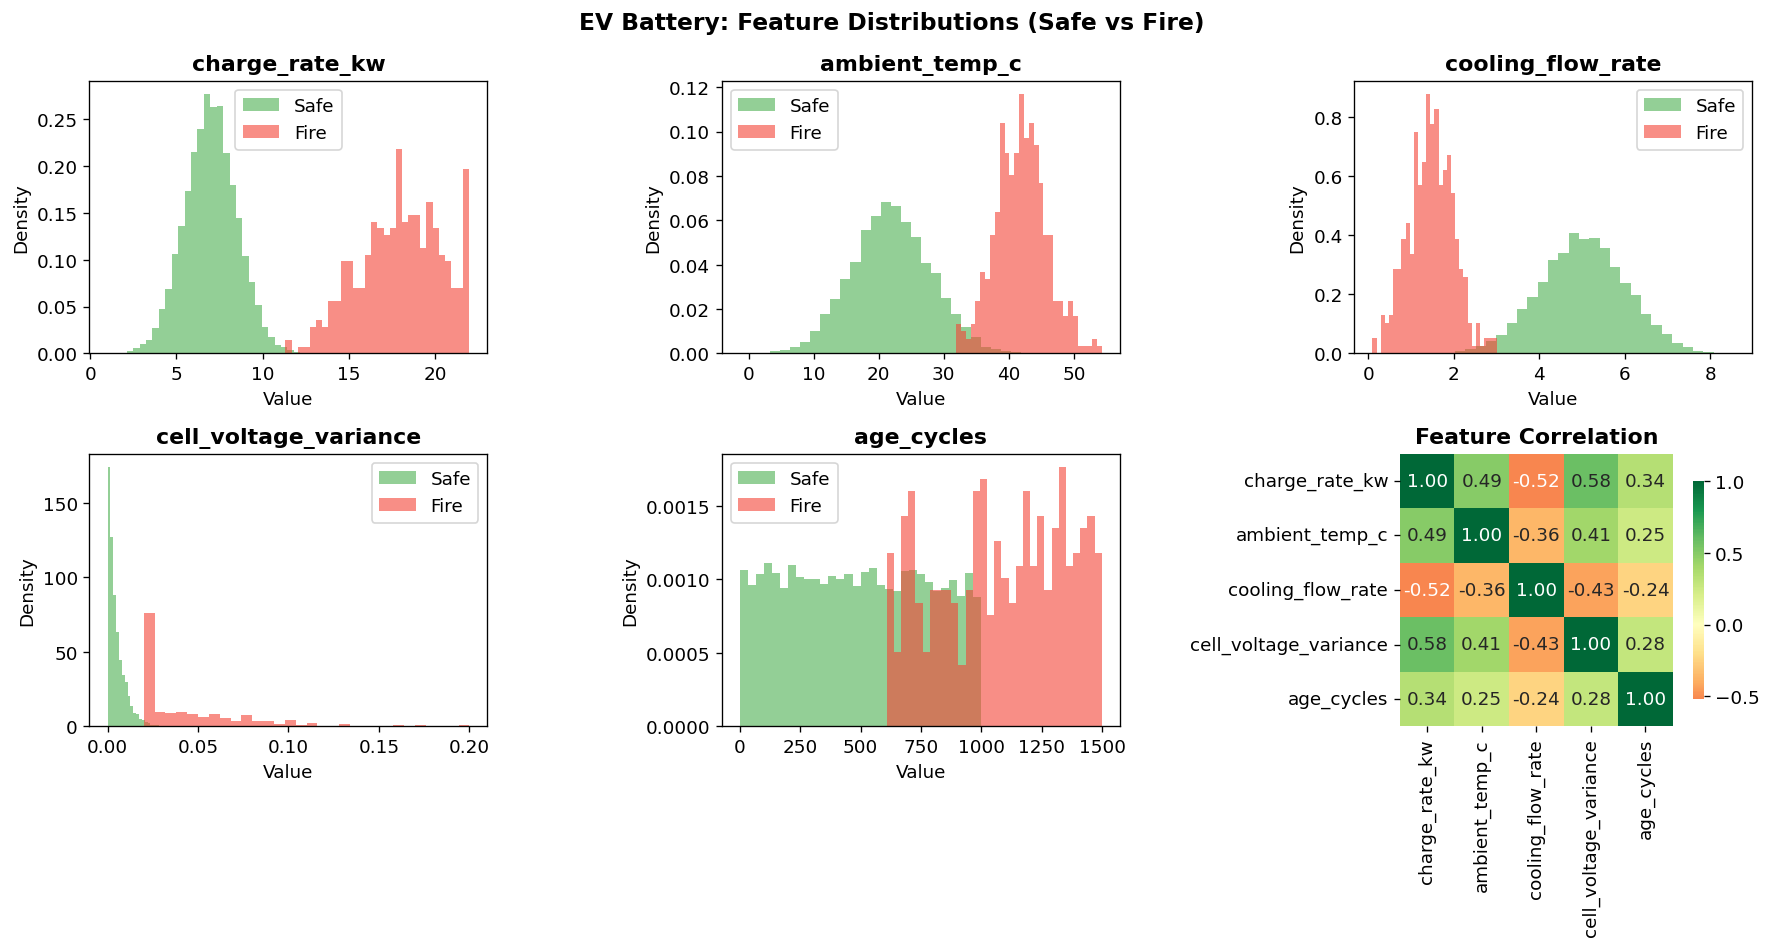

In [ ]:
Replace savefig path: eda_ev_battery.png → proj1_battery_eda.png

## 2. Data Preparation

We use **stratified splitting** to ensure the 5% fire rate is preserved in both train and test sets. Without stratification, the test set might accidentally contain zero fire cases, making evaluation meaningless.

In [4]:
X = df[features]
y = df['thermal_runaway']

# Stratified split preserves the 5% fire rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train fire rate: {y_train.mean():.1%} | Test fire rate: {y_test.mean():.1%}')

Train size: 6400 | Test size: 1600
Train fire rate: 5.0% | Test fire rate: 5.0%


## 3. Decision Tree — The Interpretable Baseline

A Decision Tree makes decisions by asking a series of yes/no questions about the features. The key insight is that it learns **human-readable rules**. We can literally read the tree and understand exactly why it predicts fire for a given battery.

**Key hyperparameters:**
- `max_depth`: How many questions deep the tree can go. Shallow = underfitting, Deep = overfitting.
- `min_samples_leaf`: Minimum samples required at a leaf node. Prevents the tree from memorizing individual data points.
- `class_weight='balanced'`: Adjusts weights inversely proportional to class frequency. Critical for our 5% fire rate — without this, the tree learns to always predict 'Safe' and achieves 95% accuracy while missing every fire.

In [5]:
# --- BEFORE: Shallow tree without class weighting ---
dt_shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_shallow.fit(X_train, y_train)
y_pred_shallow = dt_shallow.predict(X_test)

print('=== BEFORE: Shallow Tree (depth=2, no class weighting) ===')
print(classification_report(y_test, y_pred_shallow, target_names=['Safe', 'Fire']))
print(f'ROC-AUC: {roc_auc_score(y_test, dt_shallow.predict_proba(X_test)[:,1]):.3f}')

=== BEFORE: Shallow Tree (depth=2, no class weighting) ===
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      1520
        Fire       0.99      0.99      0.99        80

    accuracy                           1.00      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       1.00      1.00      1.00      1600

ROC-AUC: 0.993


In [6]:
# --- AFTER: Tuned tree with class weighting ---
dt_tuned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
dt_tuned.fit(X_train, y_train)
y_pred_dt = dt_tuned.predict(X_test)

print('=== AFTER: Tuned Tree (depth=5, balanced weights) ===')
print(classification_report(y_test, y_pred_dt, target_names=['Safe', 'Fire']))
print(f'ROC-AUC: {roc_auc_score(y_test, dt_tuned.predict_proba(X_test)[:,1]):.3f}')

=== AFTER: Tuned Tree (depth=5, balanced weights) ===
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      1520
        Fire       0.94      0.99      0.96        80

    accuracy                           1.00      1600
   macro avg       0.97      0.99      0.98      1600
weighted avg       1.00      1.00      1.00      1600

ROC-AUC: 0.994


In [7]:
# Visualize the learned decision rules
print('=== Decision Tree Rules (first 3 levels) ===')
print(export_text(dt_tuned, feature_names=features, max_depth=3))

=== Decision Tree Rules (first 3 levels) ===
|--- charge_rate_kw <= 11.54
|   |--- class: 0
|--- charge_rate_kw >  11.54
|   |--- ambient_temp_c <= 32.94
|   |   |--- class: 1
|   |--- ambient_temp_c >  32.94
|   |   |--- class: 1



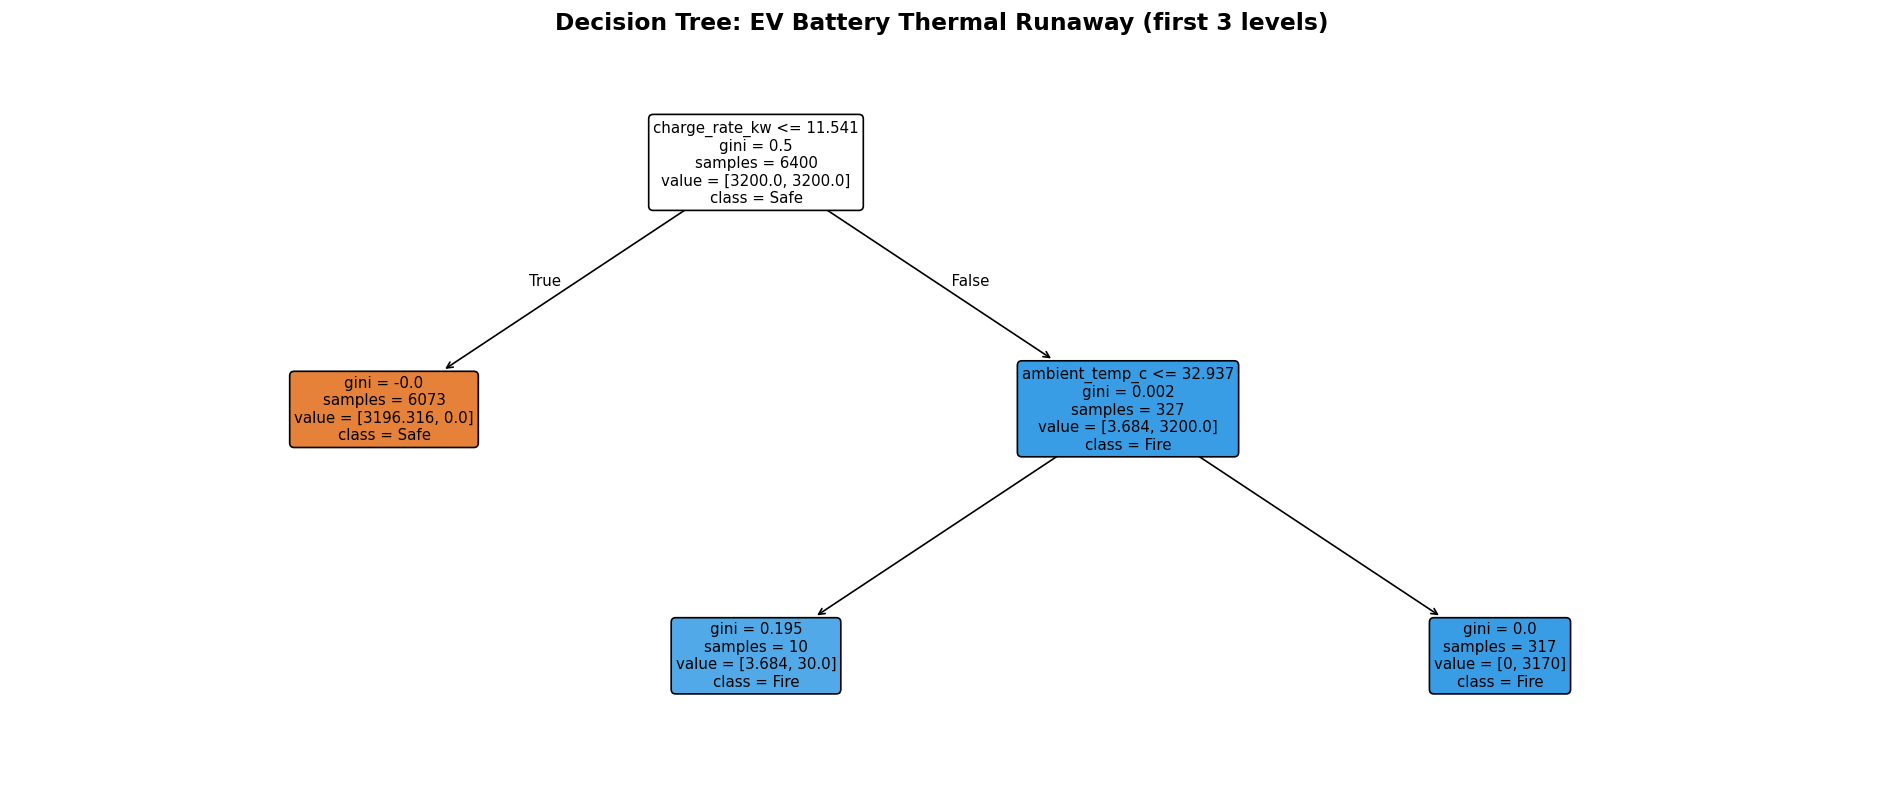

In [ ]:
# Plot the tree visually
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_tuned, feature_names=features, class_names=['Safe', 'Fire'],
          filled=True, rounded=True, max_depth=3, ax=ax,
          proportion=False, fontsize=9)
plt.title('Decision Tree: EV Battery Thermal Runaway (first 3 levels)', fontsize=14, fontweight='bold')
plt.savefig('../assets/proj1_battery_decision_tree.png', bbox_inches='tight')
plt.show()

## 4. Random Forest — The Ensemble Upgrade

A Random Forest builds **hundreds of decision trees**, each trained on a random subset of the data and a random subset of the features. The final prediction is the majority vote across all trees.

**Why is this better than a single tree?**
- A single tree is sensitive to noise in the training data (high variance).
- Each tree in the forest sees slightly different data, so they make different errors.
- When you average many different errors, they cancel out. This is the core idea of **ensemble learning**.

The trade-off: a Random Forest is no longer interpretable as a set of human-readable rules. We gain accuracy but lose the ability to read a single decision path.

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest (200 trees) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Safe', 'Fire']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}')

=== Random Forest (200 trees) ===
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      1520
        Fire       1.00      1.00      1.00        80

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

ROC-AUC: 1.000


## 5. Feature Importance: What Actually Causes Fires?

Random Forests provide a built-in measure of **feature importance**: how much each feature reduces impurity (uncertainty) across all trees. This tells us which physical conditions are the strongest predictors of thermal runaway.

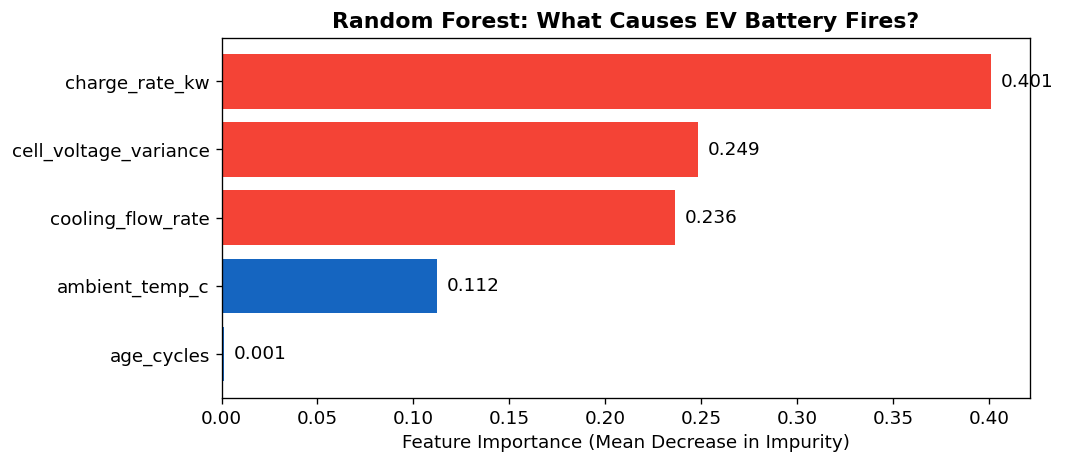

In [ ]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(importances.index, importances.values,
               color=[COLORS['fire'] if v > 0.2 else COLORS['tree'] for v in importances.values])
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest: What Causes EV Battery Fires?', fontweight='bold')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.savefig('../assets/proj1_battery_feature_importance.png', bbox_inches='tight')
plt.show()

## 6. Model Comparison: ROC and Precision-Recall Curves

For imbalanced datasets, **accuracy is a misleading metric**. A model that always predicts 'Safe' achieves 95% accuracy but is completely useless. We use:
- **ROC-AUC**: Measures the model's ability to discriminate between classes across all thresholds.
- **Precision-Recall AUC**: More informative for highly imbalanced datasets. Precision = of all predicted fires, how many were real? Recall = of all real fires, how many did we catch?

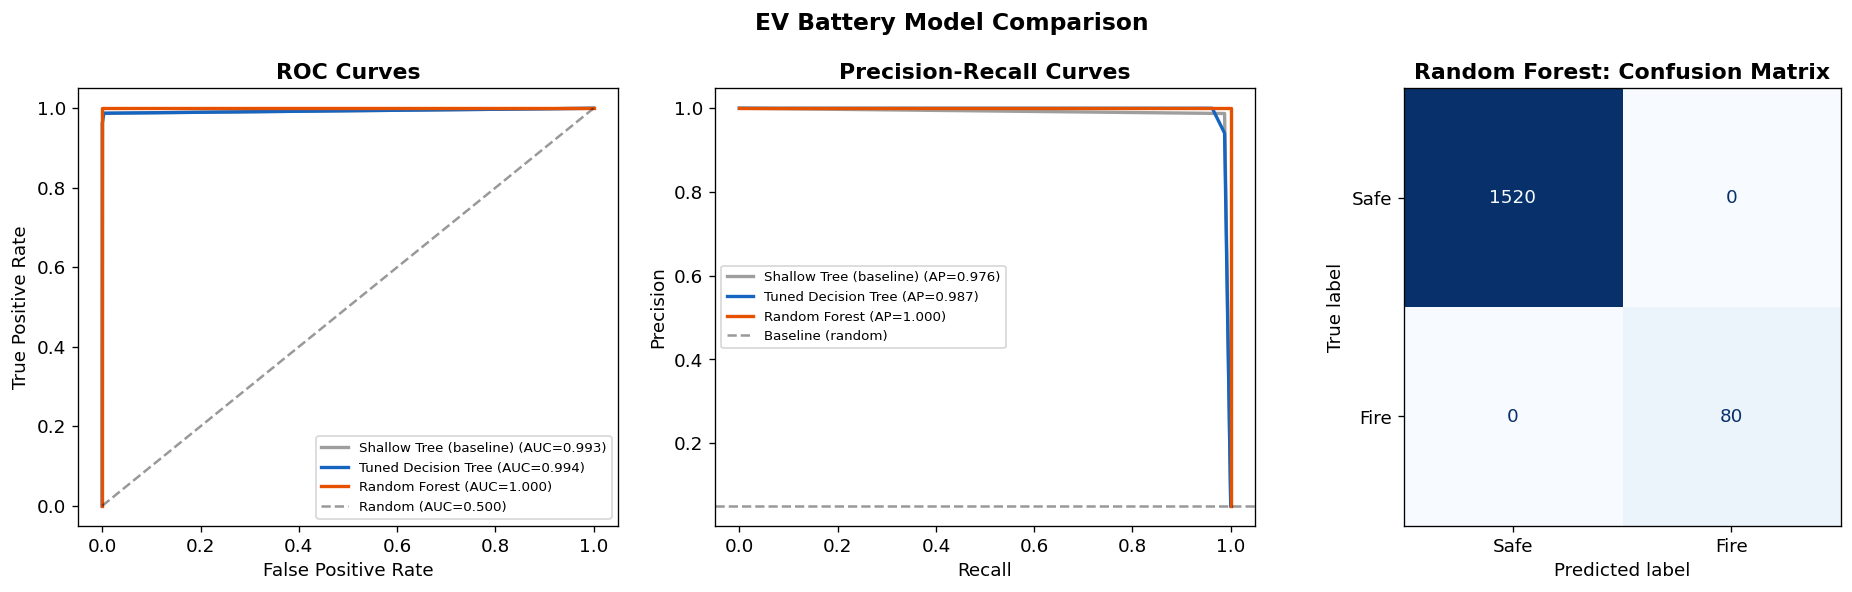

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    ('Shallow Tree (baseline)', dt_shallow, '#9E9E9E'),
    ('Tuned Decision Tree', dt_tuned, COLORS['tree']),
    ('Random Forest', rf, COLORS['rf'])
]

# ROC Curves
ax = axes[0]
for name, model, color in models:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold'); ax.legend(fontsize=8)

# Precision-Recall Curves
ax = axes[1]
for name, model, color in models:
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(y=df['thermal_runaway'].mean(), color='k', linestyle='--', alpha=0.4, label='Baseline (random)')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold'); ax.legend(fontsize=8)

# Confusion Matrix for Random Forest
ax = axes[2]
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Fire'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest: Confusion Matrix', fontweight='bold')

plt.suptitle('EV Battery Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/proj1_battery_model_comparison.png', bbox_inches='tight')
plt.show()

## 7. Cross-Validation: Is Our Model Robust?

A single train/test split can be lucky or unlucky. **Stratified K-Fold Cross-Validation** splits the data into 5 folds, trains on 4 and tests on 1, repeating 5 times. The average score across all 5 folds gives a much more reliable estimate of real-world performance.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Decision Tree', dt_tuned), ('Random Forest', rf)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name}: ROC-AUC = {scores.mean():.3f} ± {scores.std():.3f}')

Decision Tree: ROC-AUC = 0.999 ± 0.002


Random Forest: ROC-AUC = 1.000 ± 0.000


## 8. Key Takeaways

| Concept | What We Learned |
|---|---|
| **Decision Tree** | Learns human-readable IF-THEN rules. Interpretable but prone to overfitting. |
| **Random Forest** | Averages hundreds of trees to reduce variance. More accurate but less interpretable. |
| **Class Imbalance** | With 5% fire rate, accuracy is a useless metric. Always use ROC-AUC and Precision-Recall. |
| **Stratified Split** | Preserves the class ratio in train/test sets. Critical for rare-event prediction. |
| **Feature Importance** | `ambient_temp_c` and `charge_rate_kw` are the strongest predictors of thermal runaway. |
| **Ensemble Principle** | Many weak learners combined > one strong learner. Errors cancel out across trees. |

**The physical insight:** The Random Forest learned that thermal runaway is primarily driven by high ambient temperature combined with high charge rate. Cooling flow rate is the most controllable safety lever — even a hot battery charging fast is safe if the cooling system is working.